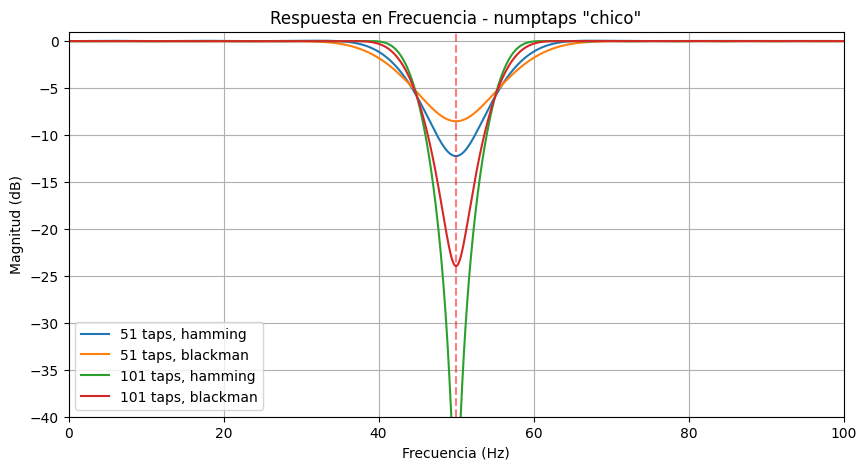

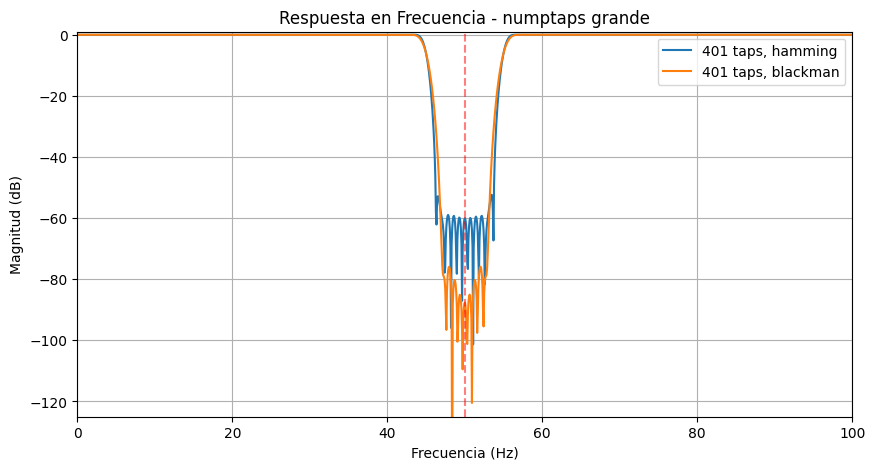

In [ ]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

fs = 300.0  # Frecuencia de muestreo
nyq = fs / 2.0
f0 = 50.0   # Frecuencia de ruido de línea
bw = 10.0    # Ancho de banda a rechazar

#de la frecuencia del ruid
edges = [(f0 - bw/2)/nyq, (f0 + bw/2)/nyq]

# --- PRIMERA GRÁFICA: 51 y 101 numtaps ---
taps_configs_1 = [(51, 'hamming'), (51, 'blackman'), (101, 'hamming'),(101, 'blackman')]

plt.figure(figsize=(10, 5))
for numtaps, window in taps_configs_1:
    taps = signal.firwin(numtaps, edges, window=window, pass_zero=True)
    w, h = signal.freqz(taps, worN=2000)
    plt.plot((w / np.pi) * nyq, 20 * np.log10(abs(h)), label=f'{numtaps} taps, {window}')

plt.title('Respuesta en Frecuencia - numptaps "chico"')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud (dB)')
plt.axvline(f0, color='r', linestyle='--', alpha=0.5)
plt.ylim(-40, 1) # Ajuste de escala para notar la diferencia
plt.xlim(0,100)
plt.legend()
plt.grid(True)
plt.show()

# --- SEGUNDA GRÁFICA: 251 numtaps ---
taps_configs_2 = [(401, 'hamming'), (401, 'blackman')]

plt.figure(figsize=(10, 5))
for numtaps, window in taps_configs_2:
    taps = signal.firwin(numtaps, edges, window=window, pass_zero=True)
    w, h = signal.freqz(taps, worN=2000)
    plt.plot((w / np.pi) * nyq, 20 * np.log10(abs(h)), label=f'{numtaps} taps, {window}')

plt.title('Respuesta en Frecuencia - numptaps grande')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud (dB)')
plt.axvline(f0, color='r', linestyle='--', alpha=0.5)
# Aquí dejamos que baje libremente para ver el verdadero potencial de los 301 taps
plt.ylim(-125, 1) # Ajuste de escala para notar la diferencia
plt.xlim(0,100)
plt.legend()
plt.grid(True)
plt.show()

Notar la magnitud en dB: En la primera grafica, podemos ver que las ventanas de Hamming, tienen un pico mejor que las de Blackman, pero con N mayores, la de blackman atenua mucho mejor!

- Si tuviera esto en algo con poder de computo, usaria Hamming, con un orden de filtro menor (-33dB ya me deja alrededor del 1%)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20572\3421401443.py:22: UserWarning: The filter's denominator is extremely small at frequencies [3.135], around which a singularity may be present
  w_iir, gd_iir = signal.group_delay((b_iir, a_iir), w=512)


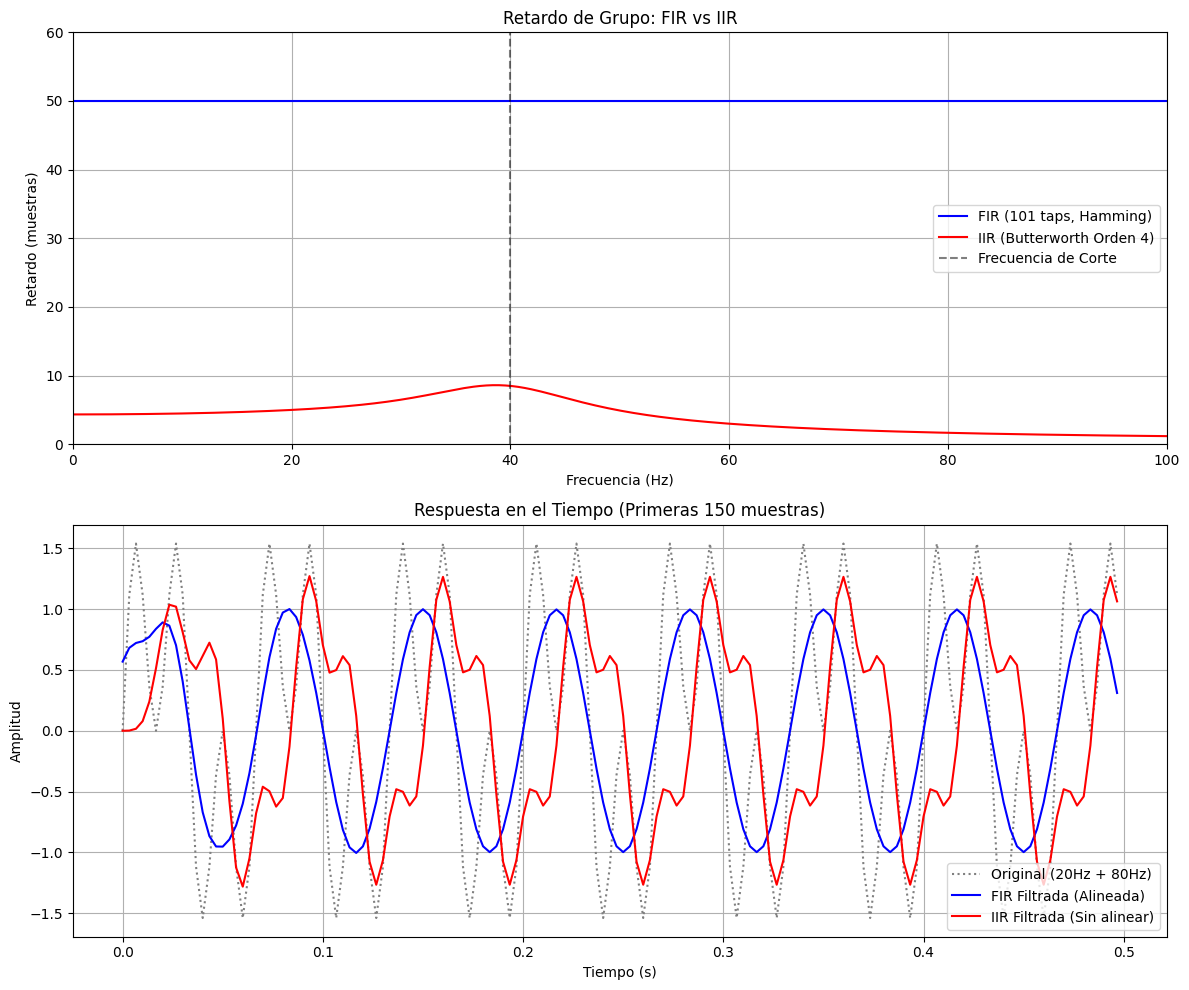

In [1]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

# Parámetros y generación de señal
fs = 300.0
nyq = fs / 2.0
t = np.arange(0, 1.0, 1.0/fs)
# Suma de senoidales de diferente frecuencia y fase cero
sig = np.sin(2 * np.pi * 15 * t) + np.sin(2 * np.pi * 45 * t)

# Diseño de filtros (Corte en 40 Hz)
taps_fir = signal.firwin(101, 40.0/nyq, window='hamming')
b_iir, a_iir = signal.butter(6, 40.0/nyq, btype='low')

# Filtrado
filtered_fir = signal.lfilter(taps_fir, 1.0, sig)
filtered_iir = signal.lfilter(b_iir, a_iir, sig)

# Cálculo de retardo de grupo
w_fir, gd_fir = signal.group_delay((taps_fir, 1), w=512)
w_iir, gd_iir = signal.group_delay((b_iir, a_iir), w=512)

# Creación de la figura
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Gráfica 1: Retardo de Grupo
ax1.plot((w_fir / np.pi) * nyq, gd_fir, label='FIR (101 taps, Hamming)', color='blue')
ax1.plot((w_iir / np.pi) * nyq, gd_iir, label='IIR (Butterworth Orden 4)', color='red')
ax1.set_title('Retardo de Grupo: FIR vs IIR')
ax1.set_xlabel('Frecuencia (Hz)')
ax1.set_ylabel('Retardo (muestras)')
ax1.axvline(40, color='k', linestyle='--', alpha=0.5, label='Frecuencia de Corte')
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 60)
ax1.legend()
ax1.grid(True)

# Gráfica 2: Respuesta en el Tiempo
# compenso el retardo de muestras
delay_fir = 50
ax2.plot(t[:150], sig[:150], label='Original (20Hz + 80Hz)', color='gray', linestyle=':')
ax2.plot(t[:150], filtered_fir[delay_fir:150+delay_fir], label='FIR Filtrada (Alineada)', color='blue')
ax2.plot(t[:150], filtered_iir[:150], label='IIR Filtrada (Sin alinear)', color='red')
ax2.set_title('Respuesta en el Tiempo (Primeras 150 muestras)')
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Amplitud')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

aca podemos ver, que el retraso del fir es constante! De 50 muestras! cumple la fase lineal, por lo que corremos la fir 50 muestras, y ya queda alineada
- El fir es de orden 101, pero esta bastante mejorcito, y tiene la fase lineal
- El iir es de orden 7, bastante mas rapido, perola fase no es lineal

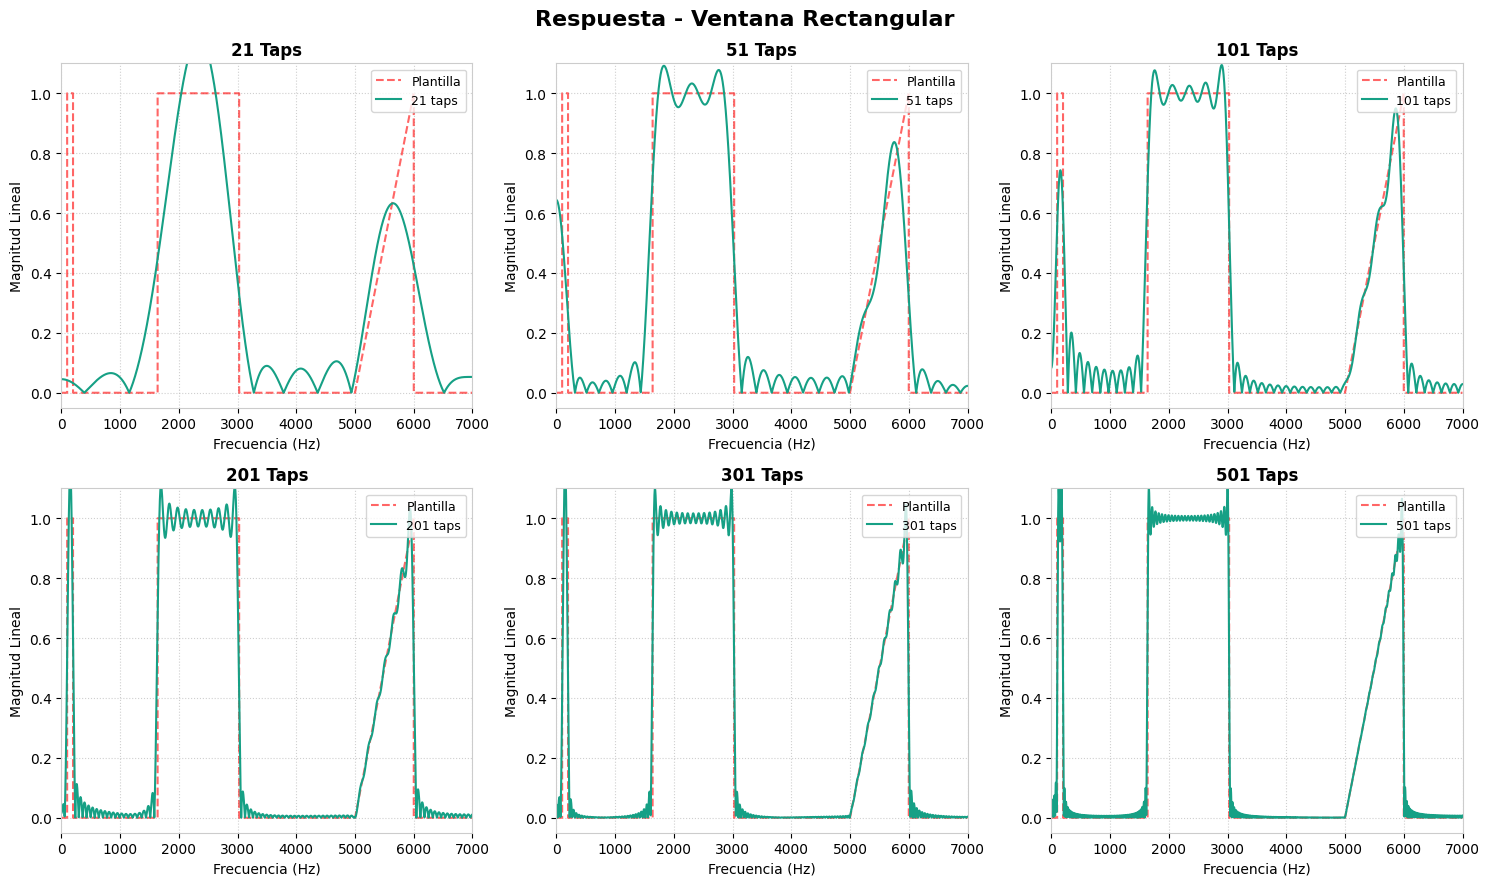

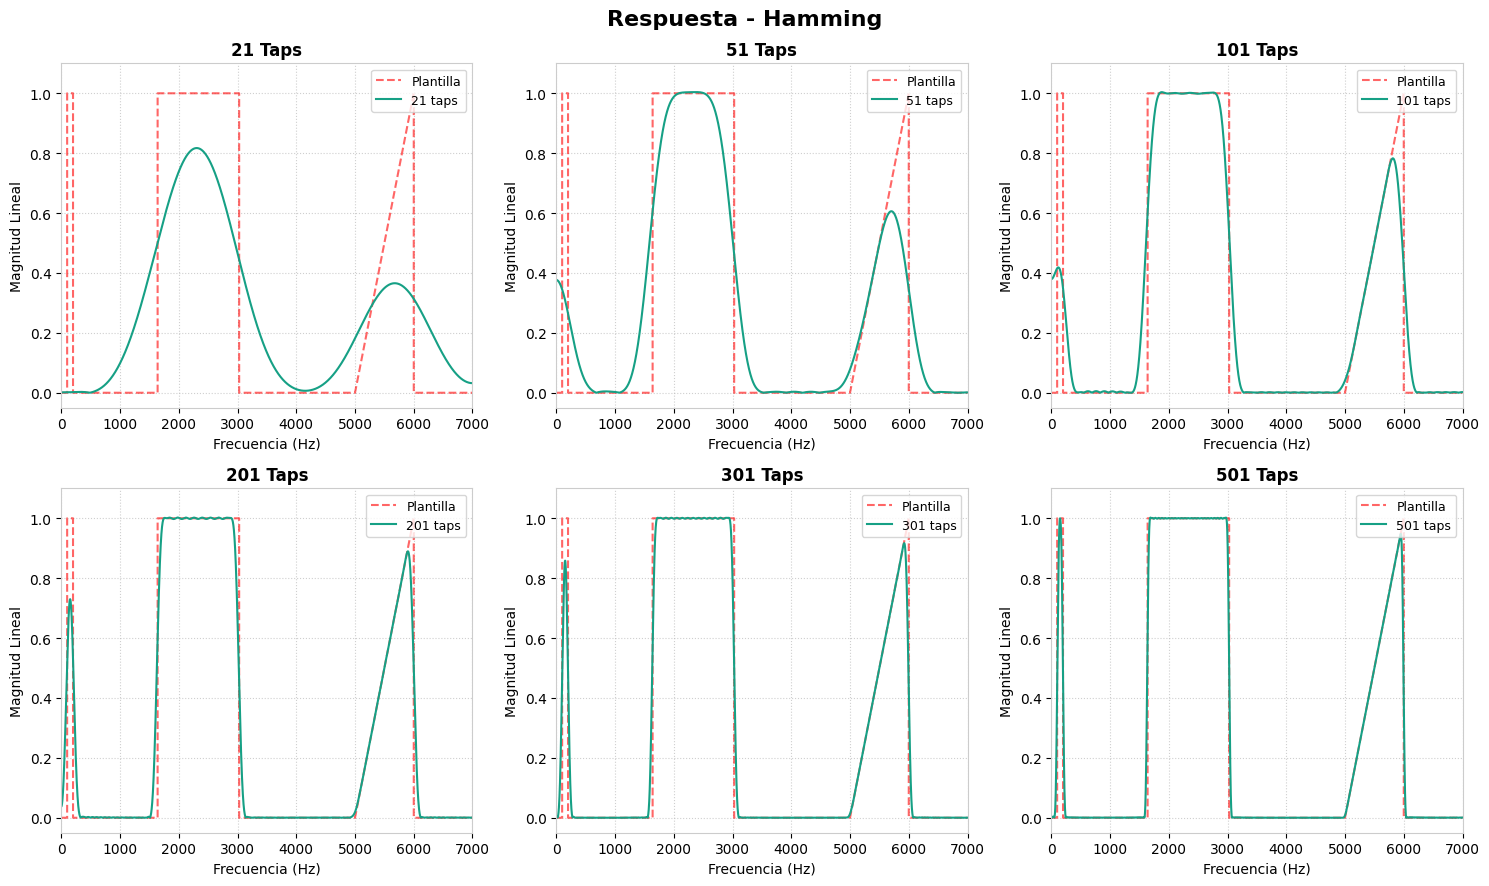

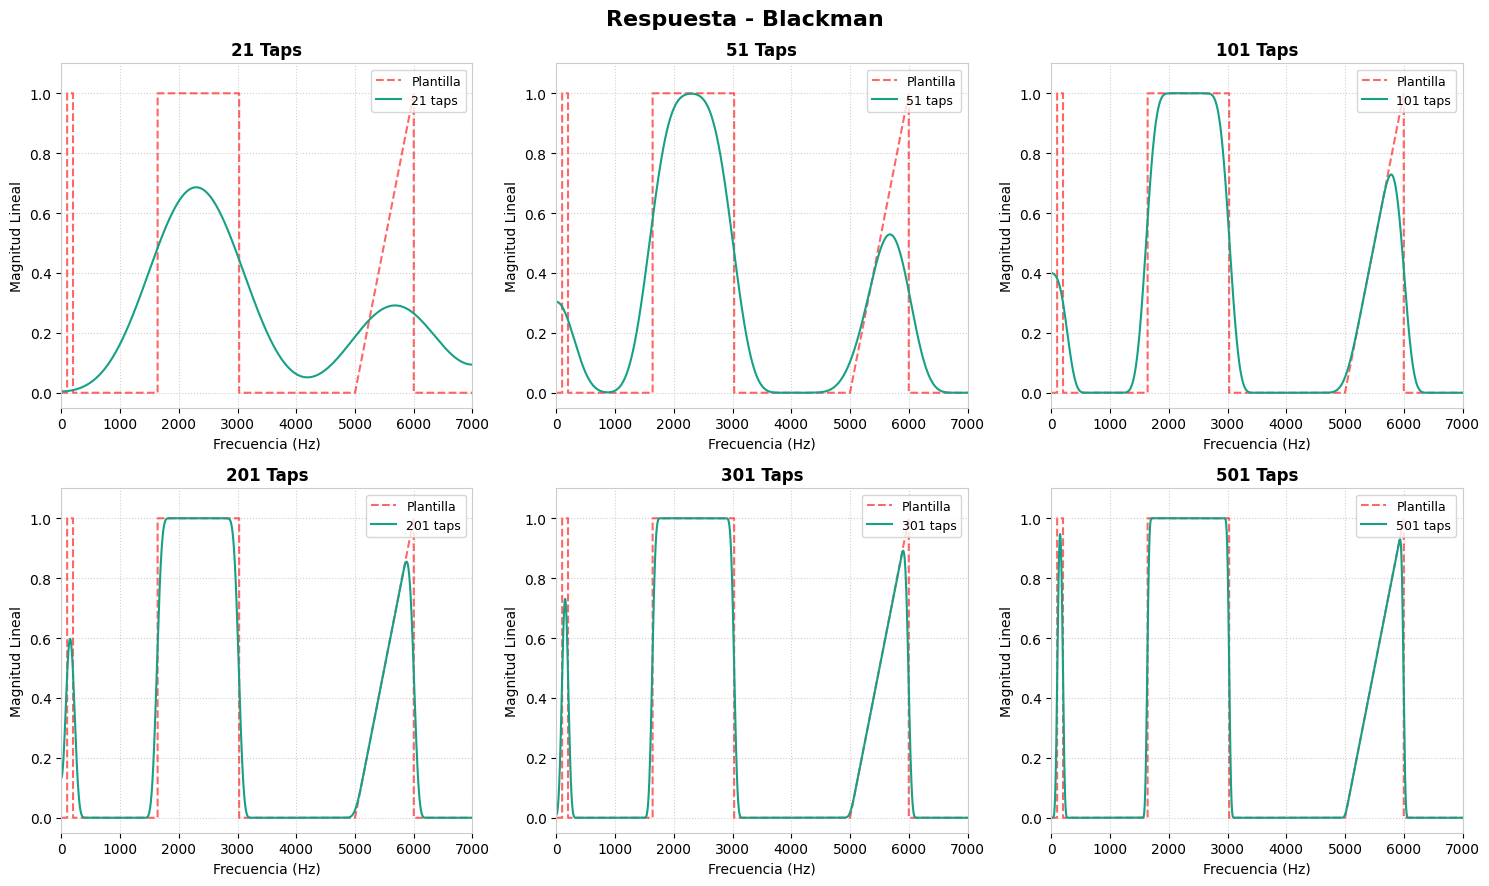

In [ ]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

# Parámetros de muestreo (Ejercicio 3)
fs_multi = 14000.0
nyq_multi = fs_multi / 2.0

# Definición de la plantilla
frequencies = [
    0,
    99.9,  100.0,       # Banda de paso 1
    200.0, 200.1,
    1639.9, 1640.0,     # Banda de paso 2
    3028.0, 3028.1,
    4999.9, 5000.0,     # Banda de paso 3 (Rampa)
    6000.0, 6000.1,
    nyq_multi
]

# Ganancias ideales en escala lineal pura (0 a 1)
gains = [0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0]

# Lista con los 6 numtaps distribuidos en la matriz 2x3
taps_list = [21, 51, 101, 201, 301, 501]
windows = ['boxcar', 'hamming', 'blackman']

for ventana in windows:
    fig, axs = plt.subplots(2, 3, figsize=(15, 9))

    if ventana == 'boxcar':
        nombre_titulo = 'Ventana Rectangular'
    elif ventana == 'hamming':
        nombre_titulo = 'Hamming'
    else:
        nombre_titulo = 'Blackman'

    # para que me arme solo la confi de plots
    for idx, numtaps in enumerate(taps_list):
        row = idx // 3
        col = idx % 3
        ax = axs[row, col]

        taps = signal.firwin2(numtaps, frequencies, gains, window=ventana, fs=fs_multi)
        w, h = signal.freqz(taps, worN=4000)

        ax.plot(frequencies, gains, 'r--', alpha=0.6, label='Plantilla')

        ax.plot((w / np.pi) * nyq_multi, np.abs(h), label=f'{numtaps} taps', color='#16a085')

        ax.set_title(f'{numtaps} Taps', fontweight='bold')
        ax.set_xlabel('Frecuencia (Hz)')
        ax.set_ylabel('Magnitud Lineal')
        ax.set_ylim(-0.05, 1.1)  # Rango fijo de 0 a 1 con margen para ver sobrepicos
        ax.set_xlim(0, nyq_multi)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper right', fontsize=9)

    plt.suptitle(f'Respuesta - {nombre_titulo}', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

Millones de graficas